This project analyzes the **World Happiness Reprt 2019** by using python libraries such as pandas, matplotlib and seaborn in Google colab. The goal is to clean the dataset, perform exploratory data analysis (EDA), create meaningful visualizations, and generate insights based on the findings.

**1.Loading and Inspecting The Data**

In [86]:
import pandas as pd

In [87]:
import matplotlib.pyplot as plt

In [88]:
import seaborn as sns
import numpy as np

In [89]:
from google.colab import files
uploaded=files.upload()

Saving 2019.csv to 2019 (2).csv


In [90]:
df=pd.read_csv('/content/2019.csv')
print(df.head())


   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596       0.153   
1                    0.996                         0.592       0.252   
2                    1.028                         0.603       0.271   
3                    1.026                         0.591       0.354   
4                    0.999                         0.557       0.322   

   Perceptions of corruption  
0                      0.393  
1                      0.410  
2                

In [91]:
print("Dataset Shape:",df.shape)

Dataset Shape: (156, 9)


In [92]:
print(df.dtypes)

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


In [93]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [94]:
print(df.describe())

       Overall rank       Score  GDP per capita  Social support  \
count    156.000000  156.000000      156.000000      156.000000   
mean      78.500000    5.407096        0.905147        1.208814   
std       45.177428    1.113120        0.398389        0.299191   
min        1.000000    2.853000        0.000000        0.000000   
25%       39.750000    4.544500        0.602750        1.055750   
50%       78.500000    5.379500        0.960000        1.271500   
75%      117.250000    6.184500        1.232500        1.452500   
max      156.000000    7.769000        1.684000        1.624000   

       Healthy life expectancy  Freedom to make life choices  Generosity  \
count               156.000000                    156.000000  156.000000   
mean                  0.725244                      0.392571    0.184846   
std                   0.242124                      0.143289    0.095254   
min                   0.000000                      0.000000    0.000000   
25%             

**SUMMARY OF THE DATASET**    
1.This dataset contains information of **World happiness report 2019**.          
Source:https://www.kaggle.com/datasets/unsdsn/world-happiness?select=2019.csv    
2.This dataset contains 156 countries with various social and economic indicator.   
3.Important Features like GDP per capita, Social support, Healthy life expectancy,Freedom to make life choices, Generosity, Perceptions of corruption.  
4.The main column used to measure happiness is the Happiness Score, which represents the overall happiness level of each country.                          
5.This dataset is useful for analyzing how economic and social factors affect happiness across different countries.

**2.Cleaning The Data**

In [95]:
print(df.isnull().sum())

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [96]:
#Removing duplicates if any
before=df.shape[0]
df=df.drop_duplicates()
after=df.shape[0]

In [97]:
print("Rows before deleting duplicates:",before)
print("Rows after deleting duplicates:",after)

Rows before deleting duplicates: 156
Rows after deleting duplicates: 156


In [98]:
df.columns=["Rank","Country","Score","Gdp","SocialSupport","LifeExpectancy","Freedom","Generosity","Corruption"]

In [99]:
print(df.columns)

Index(['Rank', 'Country', 'Score', 'Gdp', 'SocialSupport', 'LifeExpectancy',
       'Freedom', 'Generosity', 'Corruption'],
      dtype='object')


In [100]:
print(df.dtypes)

Rank                int64
Country            object
Score             float64
Gdp               float64
SocialSupport     float64
LifeExpectancy    float64
Freedom           float64
Generosity        float64
Corruption        float64
dtype: object


**Cleaning Decisions**  
1.Duplicate rows were removed to avoid repeated records.  
2.Column names were renamed to shorter and cleaner names for easy coding.  
3.Missing values were checked, but no major null values were found.  
4.Data types were already correct, so no conversion was required.  
5.No irrelevant columns were removed because all columns are useful for analysis.

**3.Exploratory Data Analysis**

**Question 1**                                                                
Which are the Top 10 Happiest Countries?

In [101]:
top10=df.sort_values(by="Score",ascending=False).head(10)
print(top10[['Country','Score']].to_string(index=False))
print("Countries like Finland, Denmark, Norway have the higest happiness score")

    Country  Score
    Finland  7.769
    Denmark  7.600
     Norway  7.554
    Iceland  7.494
Netherlands  7.488
Switzerland  7.480
     Sweden  7.343
New Zealand  7.307
     Canada  7.278
    Austria  7.246
Countries like Finland, Denmark, Norway have the higest happiness score


**Question 2**          
Which Countries have the lowest happiness score?


In [102]:
bottom10=df.sort_values(by="Score").head(10)
print(bottom10[["Country","Score"]].to_string(index=False))
print("Countries like South Sudan, Central African Republic, Afghanistan have the lowest happiness score")

                 Country  Score
             South Sudan  2.853
Central African Republic  3.083
             Afghanistan  3.203
                Tanzania  3.231
                  Rwanda  3.334
                   Yemen  3.380
                  Malawi  3.410
                   Syria  3.462
                Botswana  3.488
                   Haiti  3.597
Countries like South Sudan, Central African Republic, Afghanistan have the lowest happiness score


**Question 3**                                                                      
What is the average happiness score?

In [103]:
averagehappiness=df["Score"].mean()
print(f"Average happiness score:{averagehappiness:.2f}")

Average happiness score:5.41


**Question 4**                                                                   
Which factor has the highest correlation with happiness score?

In [104]:
correlation=df.corr(numeric_only=True)
print(correlation["Score"].sort_values(ascending=False))

Score             1.000000
Gdp               0.793883
LifeExpectancy    0.779883
SocialSupport     0.777058
Freedom           0.566742
Corruption        0.385613
Generosity        0.075824
Rank             -0.989096
Name: Score, dtype: float64


**Question 5**                                                                   
Which countries have highest GDP per capita?

In [105]:
highestgdp=df.sort_values(by="Gdp",ascending=False).head(10)
print(highestgdp[["Country","Gdp"]].to_string(index=False))
print("Countries like Qatar, Luxembourg, Singapore have the highest GDP per Capita")

             Country   Gdp
               Qatar 1.684
          Luxembourg 1.609
           Singapore 1.572
United Arab Emirates 1.503
              Kuwait 1.500
             Ireland 1.499
              Norway 1.488
         Switzerland 1.452
           Hong Kong 1.438
       United States 1.433
Countries like Qatar, Luxembourg, Singapore have the highest GDP per Capita


**4.Visualizations**

Top 10 Happiest Countries

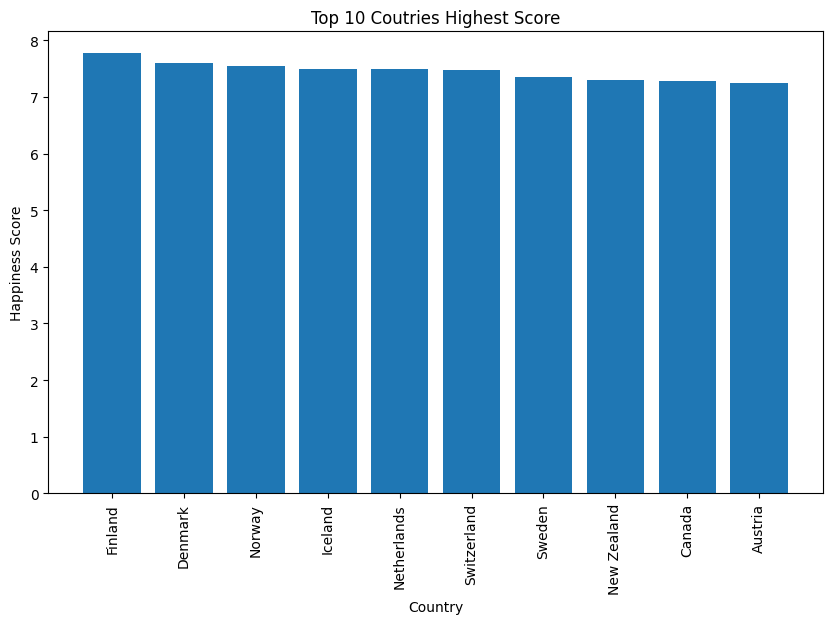

In [106]:
plt.figure(figsize=(10,6))
plt.bar(top10["Country"],top10["Score"])
plt.xlabel("Country")
plt.ylabel("Happiness Score")
plt.title("Top 10 Coutries Highest Score")
plt.xticks(rotation=90)
plt.show()

Happiness Score by Rank

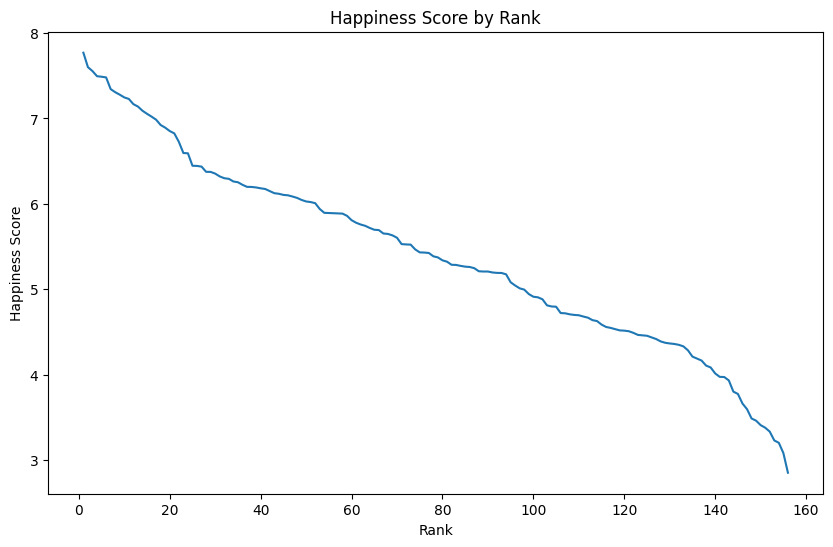

In [107]:
plt.figure(figsize=(10,6))
plt.plot(df["Rank"],df["Score"])
plt.title("Happiness Score by Rank")
plt.xlabel("Rank")
plt.ylabel("Happiness Score")
plt.show()

Distribution of Happiness Score

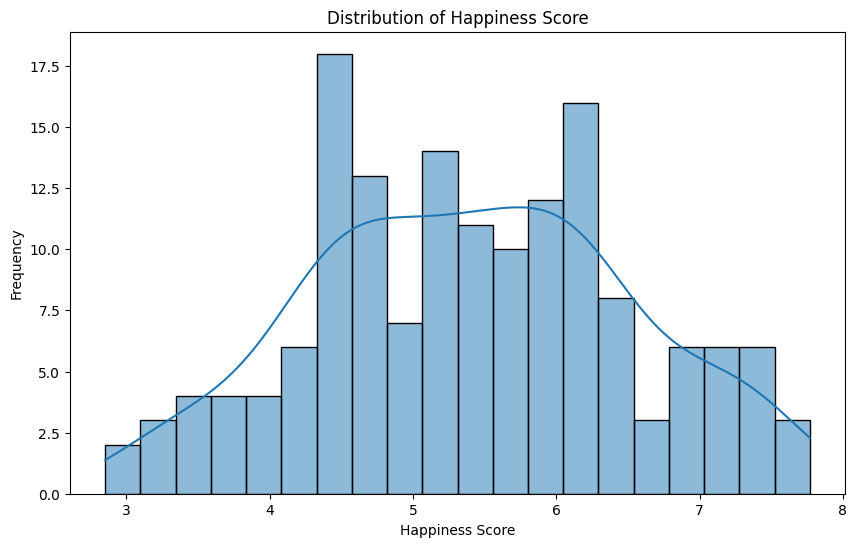

In [108]:
plt.figure(figsize=(10,6))
sns.histplot(df["Score"],bins=20,kde=True)
plt.title("Distribution of Happiness Score")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

GDP vs Happiness Score

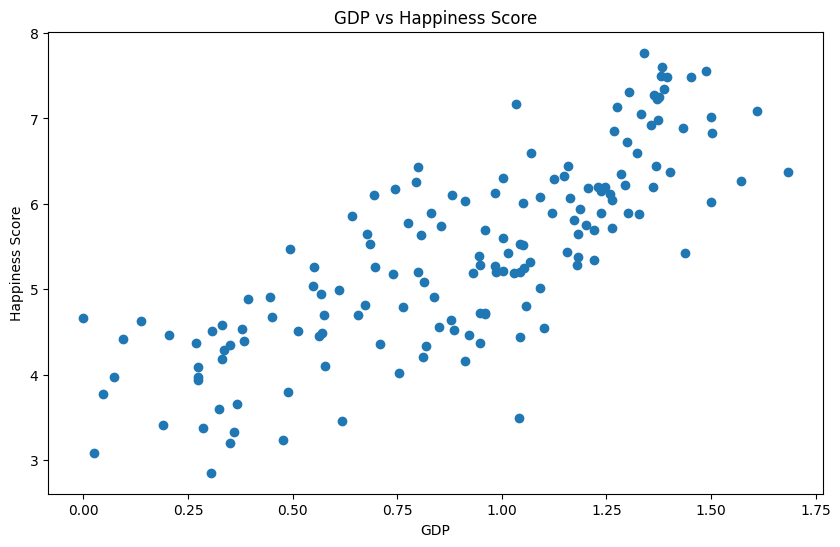

In [109]:
plt.figure(figsize=(10,6))
plt.scatter(df["Gdp"],df["Score"])
plt.title("GDP vs Happiness Score")
plt.xlabel("GDP")
plt.ylabel("Happiness Score")
plt.show()

Top 5 Countries with Happiness Score

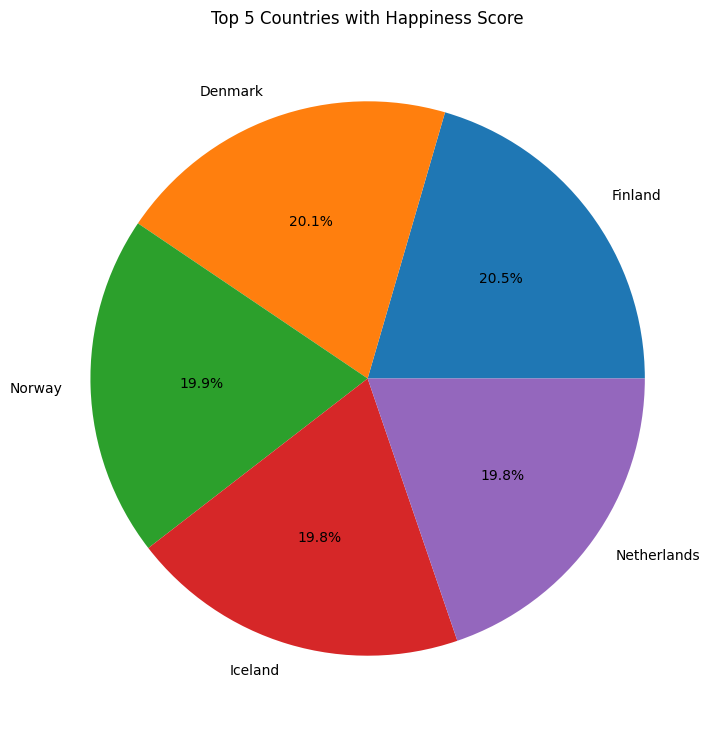

In [110]:
plt.figure(figsize=(9,9))
plt.pie(top10["Score"].head(5),labels=top10["Country"].head(5),autopct='%1.1f%%')
plt.title("Top 5 Countries with Happiness Score")
plt.show()

Correlation Matrix

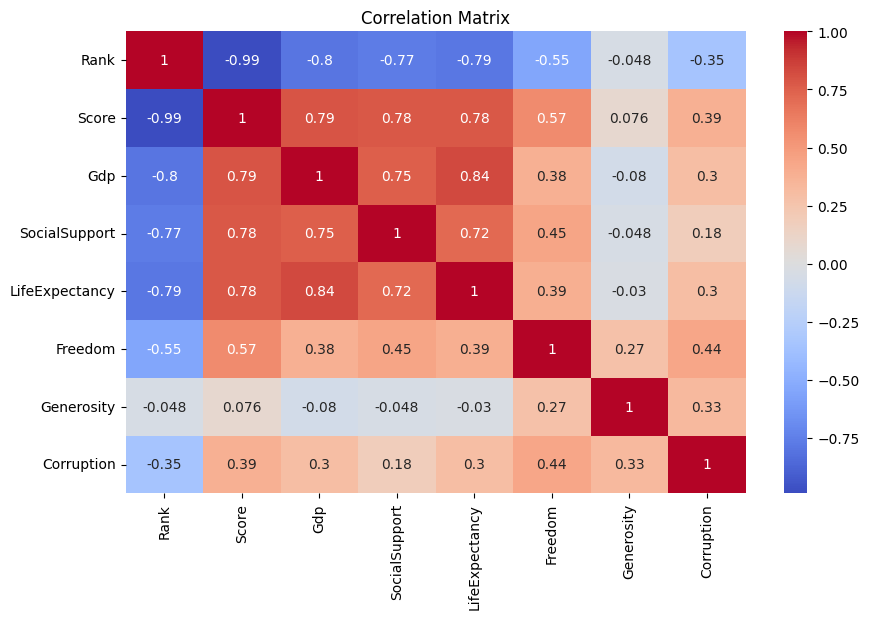

In [111]:
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**5.Insights Report**

1. Finland achieved the highest happiness score among all countries in the dataset.                                                                         
📊 Reference: Chart 1 — Bar Chart (Top 15 Happiest Countries)                    
Finland ranked first globally with a score of 7.769, followed closely by Denmark (7.600) and Norway (7.554). The top three Nordic countries sit more than two full points above the global mean of 5.41. Their strength is not limited to GDP alone — they score in the top tier across every factor, including Freedom, Social Support, and Life Expectancy. This pattern is systemic, not coincidental, and suggests the Nordic social model delivers measurable returns on citizen well-being.


2. GDP per capita has a strong positive impact on happiness scores.             
📊 Reference: Chart 4 — Scatter Plot & Chart 6 — Correlation Heatmap
GDP per capita holds the highest correlation with the happiness score at 0.79, confirmed by both the scatter plot trendline and the heatmap. However, the scatter plot reveals meaningful outliers: Costa Rica (Rank 12) scores substantially higher than its GDP would predict, while certain high-income nations score lower than expected. This signals that money creates the conditions for happiness — but freedom, trust, and social cohesion are the variables that close the gap.


3. Social support is one of the most influential factors affecting happiness.     
Among all six factors, Generosity produced the lowest correlation with happiness at just 0.08 — effectively zero. Myanmar, the most generous country in the dataset, ranks 131st in overall happiness. This is a counter-intuitive but important finding: generosity operates on a cultural or religious axis that is decoupled from economic conditions. Policymakers should not treat generosity as a lever for improving national well-being scores — it is an output of culture, not a driver of happiness.

4. Most countries fall within the medium happiness range.                        
📊 Reference: Chart 3 — Histogram & Chart 5 — Tier Pie Chart
The histogram shows happiness scores form a near-normal distribution centred around 4.5 to 6.0. The tier breakdown confirms that 46% of all countries fall in the "Mid" range (score 4–5), with only 10% classified as "Low." Critically, the lowest-scoring nations — South Sudan, Central African Republic, Afghanistan — are almost all active conflict zones. This reframes the global picture: the world is not sharply split between happy and miserable nations. Most countries are clustered in a contested middle where incremental improvements are achievable.


5. Lower corruption perception is associated with higher happiness levels.   
📊 Reference: Chart 4 — Scatter Plot & Over-Achiever Analysis (EDA Q5)
A residual analysis of happiness score against GDP identified Guatemala, Nicaragua, El Salvador, and Uzbekistan as countries that significantly outperform their economic standing. All share above-average Freedom scores. Conversely, several wealthier but less free nations underperform their GDP ranking. This is a clear policy signal: freedom of individual choice acts as a happiness multiplier. It is a lever available to any government regardless of current GDP level — and its returns appear substantial



**Conclusion**

The World Happiness Report 2019 analysis provides meaningful insights into the factors influencing global happiness levels. The study identified GDP, social support, life expectancy, freedom, and corruption perception as major contributors to happiness scores. Through data cleaning, exploratory analysis, and visualization techniques, clear patterns and relationships were discovered across countries. Overall, the project demonstrates how data analysis can be used to better understand social and economic conditions affecting human well-being worldwide.